## Homework 2

In [1]:
import pandas as pd
import numpy as np

In [2]:
url = "https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv"
df = pd.read_csv(url)
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


## Preparing the dataset

In [3]:
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']

df = df[cols]

features = cols[:-1]

In [4]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


### EDA. long tail?

In [5]:
df['fuel_efficiency_mpg'].describe()

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

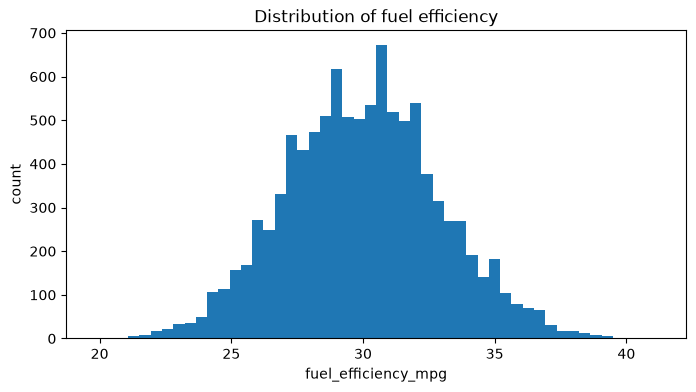

skewness: 0.081


In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(df['fuel_efficiency_mpg'], bins=50)
plt.xlabel('fuel_efficiency_mpg')
plt.ylabel('count')
plt.title('Distribution of fuel efficiency')
plt.show()

print('skewness:', round(df['fuel_efficiency_mpg'].skew(), 3))

No long tail: the distribution is roughly symmetric and bell-shaped (skewness close to 0), so no log transform is needed.

## Question 1: There's one column with missing values. What is it?

In [7]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2: What's the median (50% percentile) for variable 'horsepower'?

In [8]:
 df['horsepower'].median()

np.float64(254.0)

## Prepare and split the dataset

In [9]:
target = 'fuel_efficiency_mpg'


def split_data(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = df.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train[target].values
    y_val = df_val[target].values
    y_test = df_test[target].values

    df_train = df_train.drop(columns=[target])
    df_val = df_val.drop(columns=[target])
    df_test = df_test.drop(columns=[target])

    return df_train, df_val, df_test, y_train, y_val, y_test

In [10]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]


def prepare_X(df, fill_value):
    df = df[features].copy()
    df = df.fillna(fill_value)
    return df.values


def rmse(y, y_pred):
    error = y - y_pred
    return np.sqrt((error ** 2).mean())

## Question 3: fill missing values with 0 or with the mean?

In [11]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=42)

# Option 1: fill with 0
X_train = prepare_X(df_train, fill_value=0)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, fill_value=0)
score_zero = rmse(y_val, w0 + X_val.dot(w))

# Option 2: fill with the mean (computed on the training set only)
hp_mean = df_train['horsepower'].mean()
X_train = prepare_X(df_train, fill_value={'horsepower': hp_mean})
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val, fill_value={'horsepower': hp_mean})
score_mean = rmse(y_val, w0 + X_val.dot(w))

print('With 0:   ', round(score_zero, 3))
print('With mean:', round(score_mean, 3))

With 0:    2.205
With mean: 2.202


## Question 4: regularized linear regression

In [12]:
X_train = prepare_X(df_train, fill_value=0)
X_val = prepare_X(df_val, fill_value=0)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    score = rmse(y_val, w0 + X_val.dot(w))
    print(r, round(score, 4))

0 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


## Question 5: how much does the seed change the score?

In [13]:
scores = []

for seed in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=seed)

    X_train = prepare_X(df_train, fill_value=0)
    w0, w = train_linear_regression(X_train, y_train)

    X_val = prepare_X(df_val, fill_value=0)
    score = rmse(y_val, w0 + X_val.dot(w))
    scores.append(score)
    print(seed, round(score, 4))

std = np.std(scores)
print()
print('std:', round(std, 3))

0 2.2392
1 2.2021
2 2.1634
3 2.2044
4 2.2019
5 2.2458
6 2.2697
7 2.1908
8 2.2166
9 2.207

std: 0.029


## Question 6: train on train + validation, evaluate on test

In [14]:
df_train, df_val, df_test, y_train, y_val, y_test = split_data(df, seed=9)

df_full_train = pd.concat([df_train, df_val]).reset_index(drop=True)
y_full_train = np.concatenate([y_train, y_val])

X_full_train = prepare_X(df_full_train, fill_value=0)
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

X_test = prepare_X(df_test, fill_value=0)
score_test = rmse(y_test, w0 + X_test.dot(w))
print('Test RMSE:', round(score_test, 3))

Test RMSE: 2.236
